# EDA 06 — Composite reliability prototype (ACS sampling + imputation)

**Question.** After EDA 01–05 decomposed sampling error, privacy noise, and imputation, can we combine the two ACS-native pieces — **sampling CV** and **item allocation rate** — into a transparent reliability view that still keeps each component visible?

**Headline case.** Median household income at New Jersey tracts. Income CV and income allocation share the same household universe, so the pairing is exact rather than proxy-based.

**What this is / is not.** An exploratory two-axis matrix plus sensitivity checks for mentor review. It is **not** an official Census score. Privacy noise (EDA 04) stays out of the ACS row-level score — Decennial DHC remains a separate product track.

**Data.** ACS 5-year 2024 NJ tracts from [`analysis/acs.py`](../analysis/acs.py); allocation rates from [`analysis/alloc.py`](../analysis/alloc.py) (formulas graduated from EDA 05); boundaries from `data/raw/geo_2024_nj_tract.parquet`. Regenerate with the `/ingestion` scripts if needed.

**Thresholds (provisional).**
- CV flag: **0.30** — Census ACS quality-standard convention for estimates unreliable for most uses.
- Allocation flag: **NJ tract 75th percentile** of income allocation — exploratory sample flag, not an official cutoff.


In [37]:
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from analysis import acs, alloc
from analysis.composite import (
    QUADRANT_LABELS_PLAIN,
    QUADRANT_ORDER,
    build_reliability_frame,
    equal_weight_score,
    quadrant_counts,
    worst_component_score,
)

PROCESSED = REPO_ROOT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)
KEYS = ["STATE", "COUNTY", "TRACT"]
print("REPO_ROOT:", REPO_ROOT)


REPO_ROOT: C:\Users\justu\OneDrive\Desktop\MSBA\Capstone\Census_Uncertainty_Analysis-worktrees\granular-error-drivers-notebook


## 1. Load, join, and derive components

Join ACS estimates to allocation tables 1:1 on STATE/COUNTY/TRACT. Derive income CV (exclude top-coded medians) and income allocation rate. Keep household count as the size axis for the matched-size panel.


In [38]:
tract = acs.load_level("tract")
alloc_raw = alloc.load_level("tract")
alloc_df = alloc.derive_rates(alloc_raw)
geo = gpd.read_parquet(REPO_ROOT / "data" / "raw" / f"geo_{acs.VINTAGE}_nj_tract.parquet")

assert len(tract) == len(alloc_df) == len(geo) == 2181, (
    len(tract), len(alloc_df), len(geo)
)

rate_cols = [c for c in alloc.RATE_COLUMNS if c != "overall_alloc"]  # county-only
keep_alloc = KEYS + rate_cols + ["B99192_001E", "B99011_001E"]
df = tract.merge(alloc_df[keep_alloc], on=KEYS, how="inner", validate="one_to_one")
gdf = geo[KEYS + ["geometry"]].merge(df, on=KEYS, how="inner", validate="one_to_one")
assert len(gdf) == 2181

# Headline: income CV + income allocation
topcoded = acs.flag_topcoded_income(gdf)
gdf["cv_income"] = acs.cv(gdf["B19013_001E"], gdf["B19013_001M"]).mask(topcoded)
gdf["hh"] = gdf["B99192_001E"]  # household universe for income allocation

# Robustness: poverty CV + family-poverty allocation proxy
gdf["cv_poverty"] = acs.cv(gdf["B17001_002E"], gdf["B17001_002M"])

# Robustness: Black 65+ with handbook zero-cell RSS + age/race allocation diagnostics
gdf["black65_est"] = acs.aggregate_estimate(gdf, acs.BLACK_65PLUS_CELLS)
gdf["black65_moe"] = acs.aggregate_moe(gdf, acs.BLACK_65PLUS_CELLS, zero_rule=True)
gdf["cv_black65"] = acs.cv(gdf["black65_est"], gdf["black65_moe"])

print(f"Top-coded income tracts excluded from CV: {int(topcoded.sum())}")
print(f"Finite income CV: {int(gdf['cv_income'].notna().sum())}")
print(f"Finite income_alloc: {int(gdf['income_alloc'].notna().sum())}")
print(
    f"overall_alloc null share (expect 1.0 at tract): "
    f"{alloc_df['overall_alloc'].isna().mean():.2f}"
)
assert alloc_df["overall_alloc"].isna().all(), "B98031 should be null at tract"
print("Join + component derivation OK")


Top-coded income tracts excluded from CV: 41
Finite income CV: 2109
Finite income_alloc: 2166
overall_alloc null share (expect 1.0 at tract): 1.00
Join + component derivation OK


## 2. Headline matrix — income CV × income allocation

Classify tracts into four quadrants. The **blind spot** is low CV / high allocation: sampling looks fine, but a large share of household income values were imputed.


In [39]:
income_frame, income_thr = build_reliability_frame(
    gdf[["cv_income", "income_alloc", "hh"]].rename(columns={"cv_income": "cv"}),
    cv_col="cv",
    alloc_col="income_alloc",
)
gdf["income_quadrant"] = income_frame["quadrant"].values
gdf["income_equal_weight"] = income_frame["equal_weight_score"].values
gdf["income_worst_component"] = income_frame["worst_component_score"].values

counts = quadrant_counts(gdf["income_quadrant"])
n_classed = int(counts.sum())
print("Provisional thresholds:")
for k, v in income_thr.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
print(f"\nClassified tracts: {n_classed}")
for q in QUADRANT_ORDER:
    share = counts[q] / n_classed if n_classed else float("nan")
    print(f"  {QUADRANT_LABELS_PLAIN[q]}: {counts[q]} ({share:.1%})")

blind = counts["low_cv_high_alloc"]
print(
    f"\nBlind-spot share (CV alone would miss high imputation): "
    f"{blind / n_classed:.1%}"
)


Provisional thresholds:
  cv_threshold: 0.3000
  alloc_threshold: 0.4643
  alloc_percentile: 0.7500

Classified tracts: 2109
  Low CV / low allocation: 1522 (72.2%)
  Low CV / high allocation (blind spot): 481 (22.8%)
  High CV / low allocation: 50 (2.4%)
  High CV / high allocation: 56 (2.7%)

Blind-spot share (CV alone would miss high imputation): 22.8%


Saved C:\Users\justu\OneDrive\Desktop\MSBA\Capstone\Census_Uncertainty_Analysis-worktrees\granular-error-drivers-notebook\data\processed\eda06_income_reliability_matrix.png


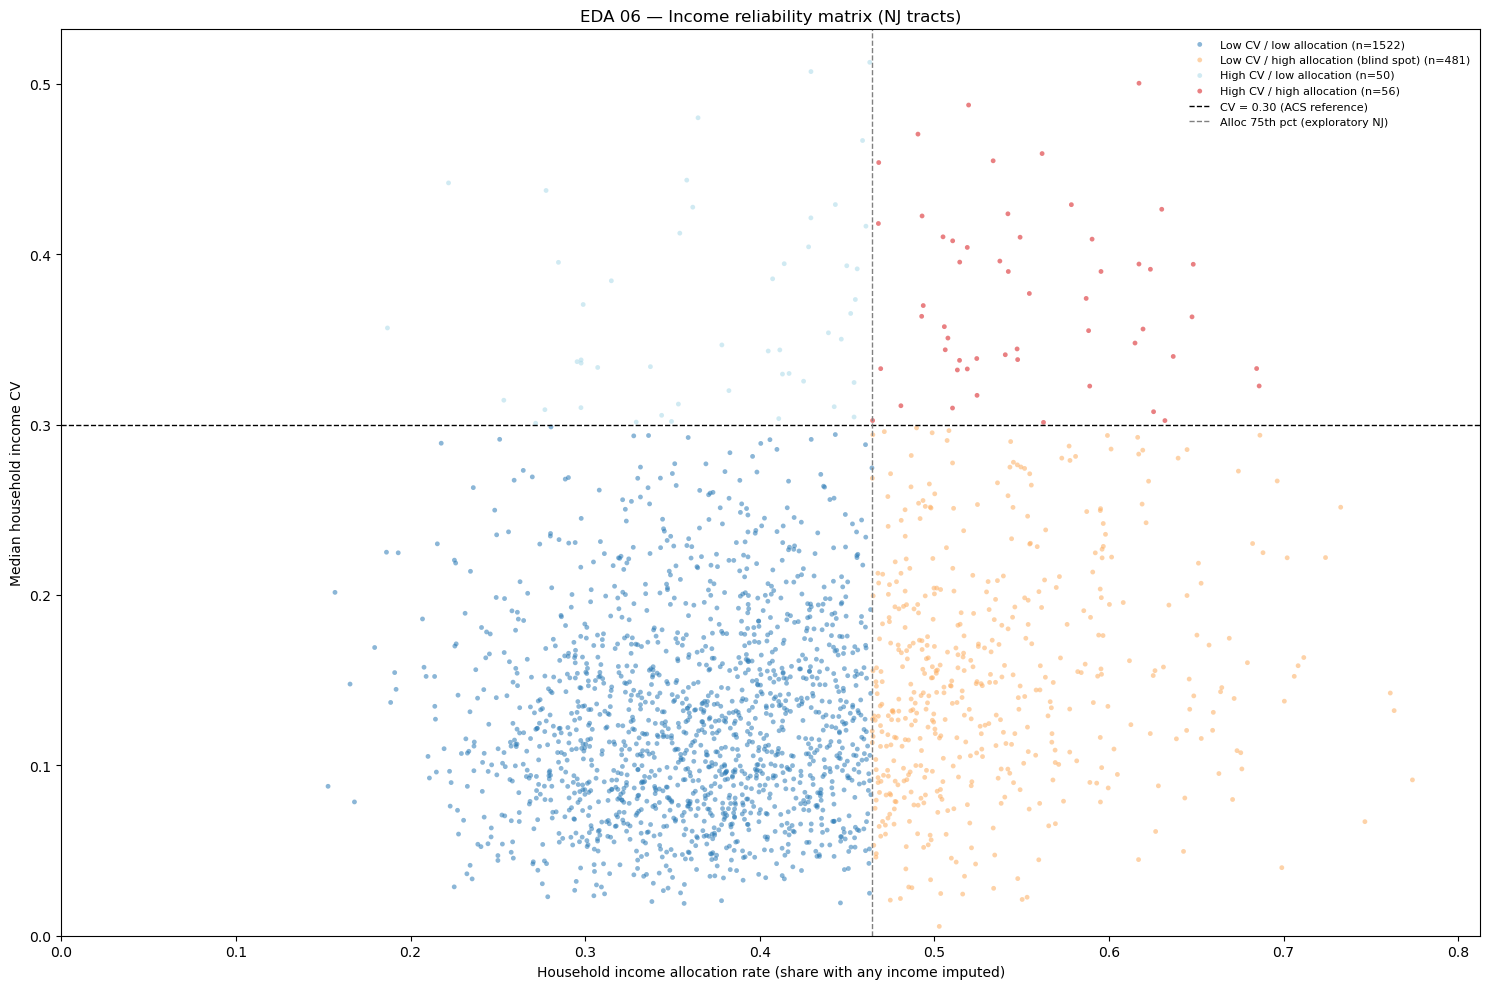

In [40]:
# Scatter matrix
fig, ax = plt.subplots(figsize=(15, 10))
colors = {
    "low_cv_low_alloc": "#2c7bb6",
    "low_cv_high_alloc": "#fdae61",
    "high_cv_low_alloc": "#abd9e9",
    "high_cv_high_alloc": "#d7191c",
}
plot = gdf.dropna(subset=["cv_income", "income_alloc", "income_quadrant"])
for q in QUADRANT_ORDER:
    sub = plot[plot["income_quadrant"] == q]
    ax.scatter(
        sub["income_alloc"],
        sub["cv_income"],
        s=12,
        alpha=0.55,
        c=colors[q],
        label=f"{QUADRANT_LABELS_PLAIN[q]} (n={len(sub)})",
        edgecolors="none",
    )
ax.axhline(
    income_thr["cv_threshold"],
    color="black",
    ls="--",
    lw=1,
    label="CV = 0.30 (ACS reference)",
)
ax.axvline(
    income_thr["alloc_threshold"],
    color="gray",
    ls="--",
    lw=1,
    label="Alloc 75th pct (exploratory NJ)",
)
ax.set_xlabel("Household income allocation rate (share with any income imputed)")
ax.set_ylabel("Median household income CV")
ax.set_title("EDA 06 — Income reliability matrix (NJ tracts)")
ax.legend(loc="upper right", fontsize=8, frameon=False)
ax.set_xlim(0, min(1.05, plot["income_alloc"].max() * 1.05))
ax.set_ylim(0, min(1.0, plot["cv_income"].quantile(0.995) * 1.15))
fig.tight_layout()
out = PROCESSED / "eda06_income_reliability_matrix.png"
fig.savefig(out, dpi=150)
print("Saved", out)
plt.show()


## 3. Map — where do the quadrants land?


Saved C:\Users\justu\OneDrive\Desktop\MSBA\Capstone\Census_Uncertainty_Analysis-worktrees\granular-error-drivers-notebook\data\processed\eda06_income_quadrant_map.png


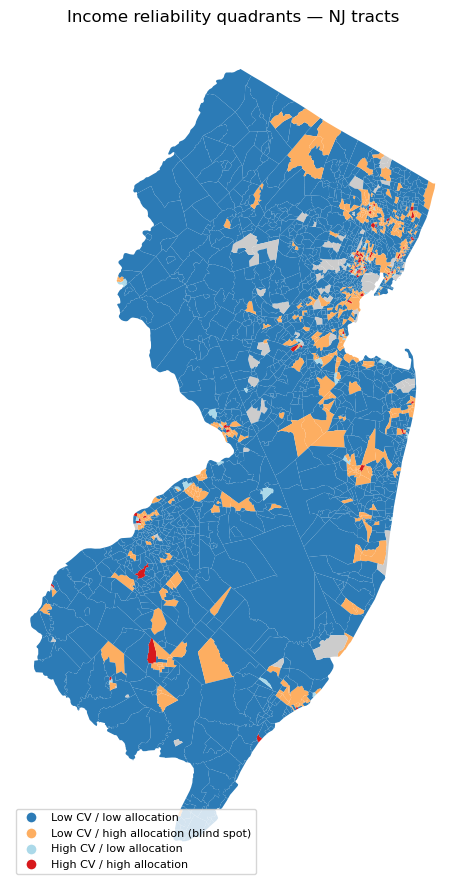

In [41]:
fig, ax = plt.subplots(figsize=(7.5, 9))
gdf_plot = gdf.copy()
gdf_plot["color"] = gdf_plot["income_quadrant"].map(colors).fillna("#cccccc")
gdf_plot.plot(color=gdf_plot["color"], ax=ax, edgecolor="none", linewidth=0)
ax.set_axis_off()
ax.set_title("Income reliability quadrants — NJ tracts")
handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=colors[q],
        markersize=8,
        label=QUADRANT_LABELS_PLAIN[q],
    )
    for q in QUADRANT_ORDER
]
ax.legend(handles=handles, loc="lower left", fontsize=8, frameon=True)
fig.tight_layout()
out = PROCESSED / "eda06_income_quadrant_map.png"
fig.savefig(out, dpi=150)
print("Saved", out)
plt.show()


## 4. Matched-size validation

Within household-count bins, tracts of similar size can still land in different quadrants. This connects EDA 02/05 (size matters for CV and confounds raw correlations) to the composite view: size alone does not determine the allocation axis.


,hh_bin,n,hh_median,alloc_p25,alloc_p75,alloc_iqr,blind_spot_share,high_both_share
0,Q1 smallest,529,937.0,0.349,0.494,0.145,0.299,0.038
1,Q2,526,1388.0,0.325,0.479,0.153,0.259,0.030
2,Q3,527,1772.0,0.340,0.464,0.124,0.228,0.021
3,Q4 largest,527,2370.0,0.321,0.433,0.112,0.127,0.017


Saved C:\Users\justu\OneDrive\Desktop\MSBA\Capstone\Census_Uncertainty_Analysis-worktrees\granular-error-drivers-notebook\data\processed\eda06_matched_size_validation.png


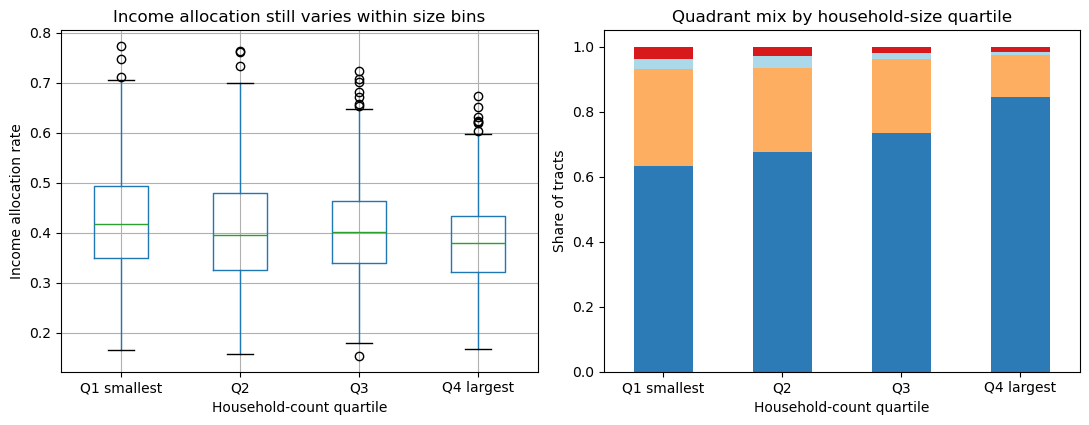

Matched-size check: allocation IQR > 0.05 in every household quartile


In [42]:
valid = gdf.dropna(subset=["hh", "income_alloc", "cv_income", "income_quadrant"]).copy()
valid = valid[valid["hh"] > 0]
valid["hh_bin"] = pd.qcut(
    valid["hh"], q=4, labels=["Q1 smallest", "Q2", "Q3", "Q4 largest"]
)

rows = []
for b, sub in valid.groupby("hh_bin", observed=True):
    qc = quadrant_counts(sub["income_quadrant"])
    rows.append(
        {
            "hh_bin": str(b),
            "n": len(sub),
            "hh_median": sub["hh"].median(),
            "alloc_p25": sub["income_alloc"].quantile(0.25),
            "alloc_p75": sub["income_alloc"].quantile(0.75),
            "alloc_iqr": sub["income_alloc"].quantile(0.75)
            - sub["income_alloc"].quantile(0.25),
            "blind_spot_share": qc["low_cv_high_alloc"] / len(sub),
            "high_both_share": qc["high_cv_high_alloc"] / len(sub),
        }
    )
size_panel = pd.DataFrame(rows)
display(size_panel.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
valid.boxplot(column="income_alloc", by="hh_bin", ax=axes[0])
axes[0].set_title("Income allocation still varies within size bins")
axes[0].set_xlabel("Household-count quartile")
axes[0].set_ylabel("Income allocation rate")
plt.suptitle("")
share = (
    valid.groupby(["hh_bin", "income_quadrant"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=list(QUADRANT_ORDER), fill_value=0)
)
share = share.div(share.sum(axis=1), axis=0)
share.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=[colors[q] for q in QUADRANT_ORDER],
    legend=False,
)
axes[1].set_title("Quadrant mix by household-size quartile")
axes[1].set_xlabel("Household-count quartile")
axes[1].set_ylabel("Share of tracts")
axes[1].tick_params(axis="x", rotation=0)
fig.tight_layout()
out = PROCESSED / "eda06_matched_size_validation.png"
fig.savefig(out, dpi=150)
print("Saved", out)
plt.show()

assert (size_panel["alloc_iqr"] > 0.05).all(), (
    "expected meaningful within-bin allocation spread"
)
print("Matched-size check: allocation IQR > 0.05 in every household quartile")


## 5. Sensitivity — equal-weight vs worst-component

Transform CV and allocation to within-sample percentile risk, then compare mean vs max. Report reclassification of the top-risk quartile rather than locking in permanent weights.


In [43]:
sens = gdf.dropna(subset=["cv_income", "income_alloc"]).copy()
sens["eq"] = equal_weight_score(sens["cv_income"], sens["income_alloc"])
sens["worst"] = worst_component_score(sens["cv_income"], sens["income_alloc"])

eq_top = sens["eq"] >= sens["eq"].quantile(0.75)
worst_top = sens["worst"] >= sens["worst"].quantile(0.75)
agree = (eq_top == worst_top).mean()
only_eq = int((eq_top & ~worst_top).sum())
only_worst = int((worst_top & ~eq_top).sum())
print(f"Top-quartile agreement (equal-weight vs worst-component): {agree:.1%}")
print(f"  In equal-weight top-Q only: {only_eq}")
print(f"  In worst-component top-Q only: {only_worst}")
print(f"  In both: {int((eq_top & worst_top).sum())}")

low_cv = sens[sens["cv_income"] <= income_thr["cv_threshold"]]
flagged_by_worst = (low_cv["worst"] >= sens["worst"].quantile(0.75)).mean()
print(
    f"\nAmong low-CV tracts, share still in worst-component top quartile: "
    f"{flagged_by_worst:.1%}"
)
print("(This is the sensitivity view of the blind-spot problem.)")


Top-quartile agreement (equal-weight vs worst-component): 84.6%
  In equal-weight top-Q only: 162
  In worst-component top-Q only: 162
  In both: 366

Among low-CV tracts, share still in worst-component top quartile: 21.1%
(This is the sensitivity view of the blind-spot problem.)


## 6. Robustness cases (explicitly labeled)

- **Poverty:** person-level poverty CV paired with **family-universe** allocation proxy (`fam_pov_alloc`) — not an exact pairing.
- **Black 65+:** handbook zero-cell RSS CV paired with age/race allocation means as **diagnostic** axes — no age×race income-style allocation table for this subgroup.


In [44]:
def summarize_case(name, cv_s, alloc_s, alloc_label):
    frame, thr = build_reliability_frame(
        pd.DataFrame({"cv": cv_s, "alloc": alloc_s}),
        cv_col="cv",
        alloc_col="alloc",
    )
    case_counts = quadrant_counts(frame["quadrant"])
    n = int(case_counts.sum())
    print(f"\n=== {name} ===")
    print(f"Allocation axis: {alloc_label}")
    print(
        f"CV threshold={thr['cv_threshold']:.2f}; "
        f"alloc 75th={thr['alloc_threshold']:.4f}"
    )
    print(f"Classified n={n}")
    for q in QUADRANT_ORDER:
        print(
            f"  {QUADRANT_LABELS_PLAIN[q]}: "
            f"{case_counts[q]} ({case_counts[q]/n:.1%})"
        )
    print(f"Blind-spot share: {case_counts['low_cv_high_alloc']/n:.1%}")
    return frame, thr, case_counts


_, _, pov_counts = summarize_case(
    "Poverty (PROXY pairing)",
    gdf["cv_poverty"],
    gdf["fam_pov_alloc"],
    "fam_pov_alloc (family universe — labeled proxy)",
)

demo_diag = gdf[["age_alloc", "race_alloc"]].mean(axis=1)
_, _, b65_counts = summarize_case(
    "Black 65+ (DIAGNOSTIC allocation axis)",
    gdf["cv_black65"],
    demo_diag,
    "mean(age_alloc, race_alloc) — not a subgroup-specific allocation table",
)

print(
    "\nNote: robustness cases illustrate method portability; "
    "income remains the headline exact pairing."
)



=== Poverty (PROXY pairing) ===
Allocation axis: fam_pov_alloc (family universe — labeled proxy)
CV threshold=0.30; alloc 75th=0.4979
Classified n=2158
  Low CV / low allocation: 287 (13.3%)
  Low CV / high allocation (blind spot): 142 (6.6%)
  High CV / low allocation: 1332 (61.7%)
  High CV / high allocation: 397 (18.4%)
Blind-spot share: 6.6%

=== Black 65+ (DIAGNOSTIC allocation axis) ===
Allocation axis: mean(age_alloc, race_alloc) — not a subgroup-specific allocation table
CV threshold=0.30; alloc 75th=0.0193
Classified n=1596
  Low CV / low allocation: 133 (8.3%)
  Low CV / high allocation (blind spot): 67 (4.2%)
  High CV / low allocation: 1058 (66.3%)
  High CV / high allocation: 338 (21.2%)
Blind-spot share: 4.2%

Note: robustness cases illustrate method portability; income remains the headline exact pairing.


## 7. Findings (plain English)

1. **Two axes stay visible.** The income matrix keeps sampling CV and imputation rate as separate coordinates. Equal-weight / worst-component scores are sensitivity checks, not replacements for the matrix.
2. **CV alone misses a real blind spot.** A substantial share of classified tracts have CV ≤ 0.30 but income allocation above the exploratory NJ 75th percentile — these look "fine" on MOE-based CV yet have high imputation.
3. **Size does not collapse the allocation axis.** Within household-count quartiles, income allocation still spreads (IQR stays material) and quadrant mixes differ — matching EDA 05's size-controlled independence story.
4. **Combination rule matters at the margin.** Equal-weight and worst-component disagree on who sits in the top-risk quartile; report that disagreement rather than pretending weights are settled.
5. **Prototype boundaries.** Thresholds and weights are provisional. Privacy noise is not row-joined. Poverty and Black 65+ are labeled robustness/diagnostic cases, not exact pairings.

### Mentor decisions needed
- Tier philosophy: keep the visible two-axis matrix, or collapse to a single weighted score for the dashboard?
- Keep empirical DHC privacy RMSE as a **separate product score**, not mixed into ACS rows?
- Accept proxy/diagnostic pairings for poverty and Black 65+ in the concept pitch, with labels?


In [45]:
# Final assertions for clean re-run
assert n_classed > 2000
assert counts["low_cv_high_alloc"] > 0
assert 0 < agree < 1
print("EDA 06 verification assertions passed.")
print("Charts:", sorted(p.name for p in PROCESSED.glob("eda06_*.png")))


EDA 06 verification assertions passed.
Charts: ['eda06_income_quadrant_map.png', 'eda06_income_reliability_matrix.png', 'eda06_matched_size_validation.png']
